# Applications of the lower bound of movement for Chagas detection (v1)

These notebook explains how the lower bounds of movement determinated in [Final Stats](EstadísticasFinales.ipynb) can be used for a detection algorithm.

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

Parameters for Färneback algorithm of the experiment

In [4]:
# Parameters of Färneback algoritm of the experiment
farneback_params = dict(
    pyr_scale=0.5,  # Image scale (<1) to build pyramids for each image
    levels=3,       # Number of pyramid layers
    winsize=15,     # Averaging window size
    iterations=3,   # Number of iterations at each pyramid level
    poly_n=5,       # Size of the pixel neighborhood for polynomial expansion
    poly_sigma=1.2, # Standard deviation for polynomial expansion
    flags=0         # Additional flags (optional)
    )

To simplify the proccess, this functions make the Magnitud test characteristics

In [5]:
def MagnitudeTest(video, cota, frames, x0=0, x1 = 1920):
    # Storage
    pts = np.empty((0,2))
    
    ret, old_frame = video.read()
    if not ret:
        print('No hay video')

    old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
    old_gray = old_gray[0:1080, x0:x1]

    for _ in range(frames):
        ret, frame = video.read()
        if not ret:
            break

        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame_gray = frame_gray[0:1080, x0:x1]

        #Calculate dense optical flow using Farneback method
        flow = cv2.calcOpticalFlowFarneback(old_gray, frame_gray, None, **farneback_params)
        old_gray = frame_gray

        # Compute magnitude and angle of the flow vectors
        magnitude, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])

        # Coordenates of selected values
        new_pts = np.column_stack(np.where(magnitude > cota))

        # Remove duplications of coordenates
        pts = np.unique(np.vstack((new_pts, pts)), axis = 0)
        
    return pts

In [6]:
def clustering(pts, min_pts = 25, radius = 25):
    dbscan = DBSCAN(eps = radius, min_samples = min_pts) 
    labels = dbscan.fit_predict(pts)

    # Lista de clusters
    clusters = [k for k in set(labels) if k != -1]

    # Separación de puntos en su respectivo cluster
    ref_cluster = []
    for k in clusters:  # Dividir los puntos iniciales en los clusters
        puntos_en_cluster = [pts[i] for i in range(len(labels)) if labels[i] == k]
        pts_cluster = np.array(puntos_en_cluster)
        mean = int(len(pts_cluster)/2)
        ref_cluster.append(pts_cluster[mean]) # The representative is the half point of the cluster

    return(np.array(ref_cluster))

# Video without interface

The first case is to show the results when no interface is presented. At this case we used the lower bounds of Pos99 and Pos95.

In [8]:
Pos99, Pos95 = 2.4856, 1.8334 # Cotas de movimiento

In [9]:
video = cv2.VideoCapture('Videos/chagas56.MOV')
_, frame0 = video.read()

## Case for Pos99

In [11]:
pts = MagnitudeTest(video, Pos99, 5)

### Clustering
Applying the selected coordenates in a DSCAN algorithm, is possible to define zones of interes. This zones can be characterize by a square of followilling the trayectory of one of the points. 

In [13]:
detect = clustering(pts, min_pts = 25)

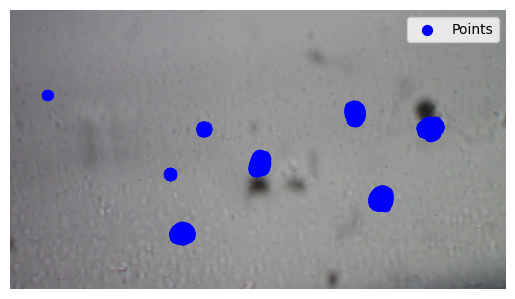

In [14]:
plt.imshow(frame0)
plt.scatter(pts[:,1], pts[:,0], color= "blue", s=50, label="Points")
# plt.title('Example video')
plt.legend()
plt.axis('off')
#plt.savefig('goodpts.png', bbox_inches='tight', pad_inches=0)
plt.show()

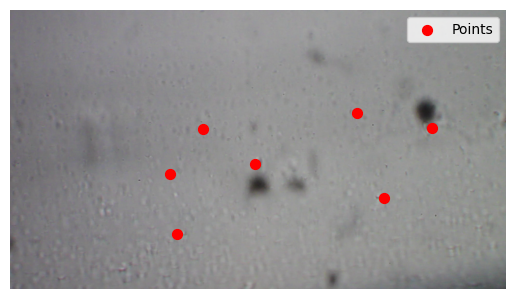

In [15]:
# Show image with the clusters representatives.
plt.imshow(frame0)
plt.scatter(detect[:,1], detect[:,0], color= "red", s=50, label="Points")  # Se usa como marcador el punto del intermedio
#plt.title('Example video')
plt.legend()
plt.axis('off')
# plt.savefig('clusters.png', bbox_inches='tight', pad_inches=0)
plt.show()

### ROI's in Image

To remark the regions of detection, for each point was build a window bigger enough to highlight a small zone without bloking the vision of a possible parasite. As the lenght of the patches was 50 pts, we take that as the radious of the windows.

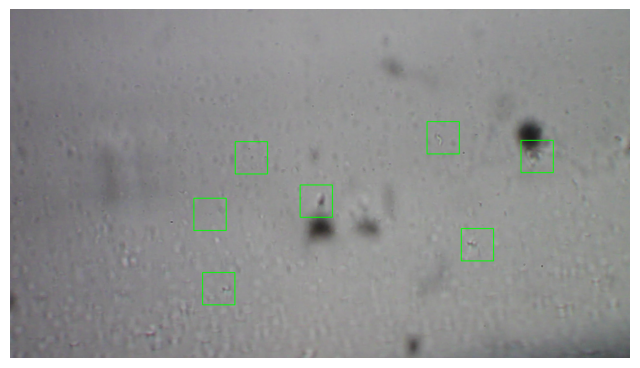

In [17]:
# Longitud del lado del cuadrado
radio = 50 

# Draw the rectangles over the image.
for (y, x) in detect:
    top_left = (int(x) - radio, int(y) - radio)
    bottom_right = (int(x) + radio, int(y) + radio)
    cv2.rectangle(frame0, top_left, bottom_right, (0, 255, 0), 2)  # Color verde, grosor 2px

plt.figure(figsize=(8, 6))
plt.imshow(frame0)
#plt.title("Imagen con puntos y cuadrados")
plt.axis("off")
# plt.savefig('section.png', bbox_inches='tight', pad_inches=0)
plt.show()

## Case of Pos95

In [19]:
pts = MagnitudeTest(video, Pos95, 5)
_, frame0 = video.read()

## Clustering

In [21]:
detect = clustering(pts, min_pts = 125)

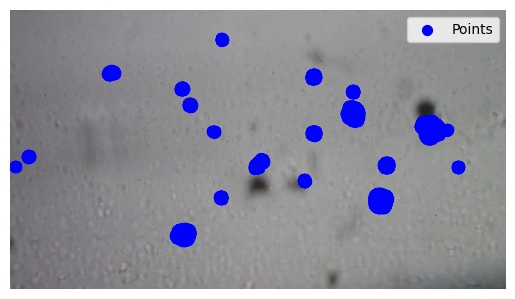

In [22]:
plt.imshow(frame0)
plt.scatter(pts[:,1], pts[:,0], color= "blue", s=50, label="Points")
# plt.title('Example video')
plt.legend()
plt.axis('off')
#plt.savefig('goodpts.png', bbox_inches='tight', pad_inches=0)
plt.show()

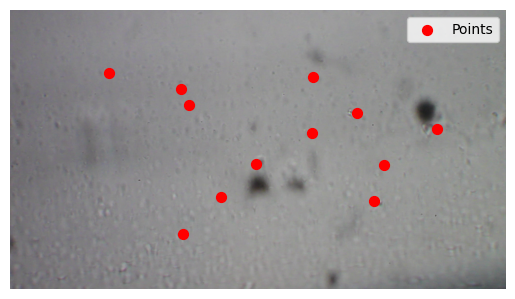

In [23]:
# Show image with the clusters representatives.
plt.imshow(frame0)
plt.scatter(detect[:,1], detect[:,0], color= "red", s=50, label="Points")  # Se usa como marcador el punto del intermedio
#plt.title('Example video')
plt.legend()
plt.axis('off')
# plt.savefig('clusters.png', bbox_inches='tight', pad_inches=0)
plt.show()

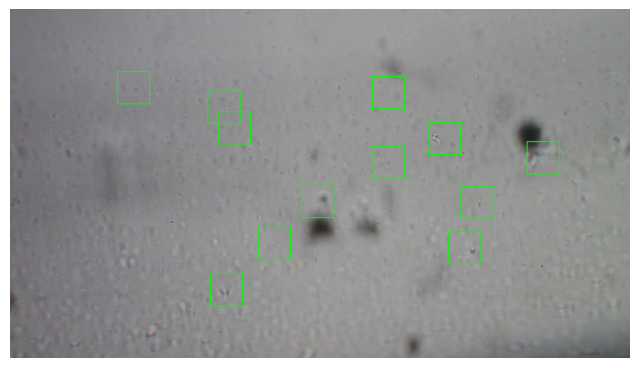

In [24]:
# Longitud del lado del cuadrado
radio = 50 

# Draw the rectangles over the image.
for (y, x) in detect:
    top_left = (int(x) - radio, int(y) - radio)
    bottom_right = (int(x) + radio, int(y) + radio)
    cv2.rectangle(frame0, top_left, bottom_right, (0, 255, 0), 2)  # Color verde, grosor 2px

plt.figure(figsize=(8, 6))
plt.imshow(frame0)
#plt.title("Imagen con puntos y cuadrados")
plt.axis("off")
# plt.savefig('section.png', bbox_inches='tight', pad_inches=0)
plt.show()

# Video with Interface

In [26]:
video = cv2.VideoCapture('Videos/chagas47.MOV')
_ , frame0 = video.read()
frame0_color = (cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB))

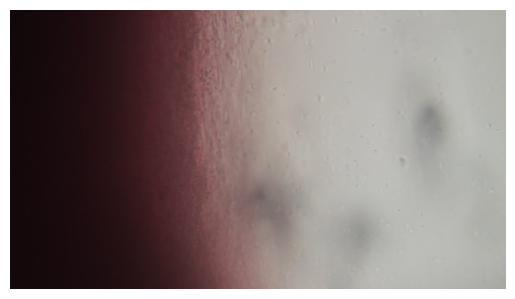

In [27]:
plt.imshow(frame0_color)
plt.axis('off')
plt.show()

## Sobel filter

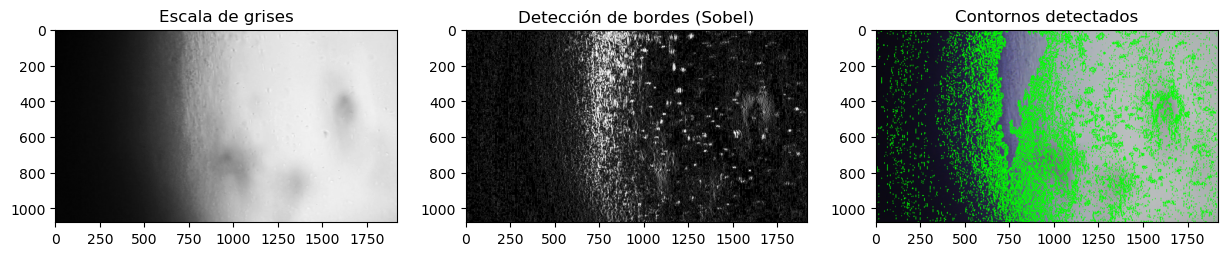

In [29]:
# Escala de grises
gray = cv2.cvtColor(frame0, cv2.COLOR_BGR2GRAY)

# Aplicar un filtro de detección de bordes (Sobel en X para detectar cambios verticales)
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
sobelx = cv2.convertScaleAbs(sobelx)  # Convertir a valores de píxeles visibles

# Aplicar un umbral para segmentar la zona de mayor cambio
_, thresh = cv2.threshold(sobelx, 50, 255, cv2.THRESH_BINARY)

# Encontrar contornos en la imagen umbralizada
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Dibujar los contornos sobre la imagen original
img_contours = frame0.copy()
cv2.drawContours(img_contours, contours, -1, (0, 255, 0), 2)

# Mostrar los resultados
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(gray, cmap='gray')
axs[0].set_title("Escala de grises")

axs[1].imshow(sobelx, cmap='gray')
axs[1].set_title("Detección de bordes (Sobel)")

axs[2].imshow(img_contours)
axs[2].set_title("Contornos detectados")
plt.show()

In [30]:
largest_contour = max(contours, key=cv2.contourArea)

In [31]:
# Obtener un bounding box alrededor del contorno
x, _, w, _ = cv2.boundingRect(largest_contour)

In [32]:
x0 = x
x1 = x + w

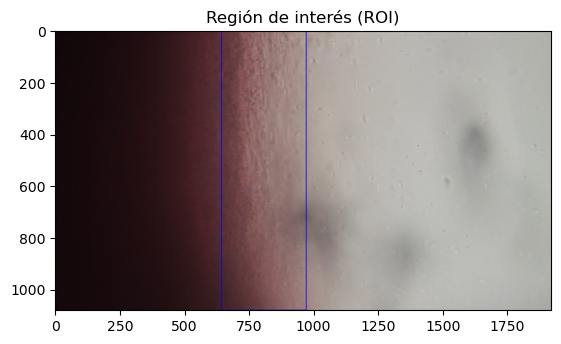

In [33]:
# Recortar la región de interés (ROI)
cv2.rectangle(frame0_color, (x0, 0), (x1, 1080), (0, 0, 255), thickness=2) # Se suman 25 para longitud de radio

# Mostrar la ROIfilte
plt.imshow(frame0_color)
plt.title("Región de interés (ROI)")
plt.show()

## Movement detection

In [35]:
InterPos99, InterPos95 = 1.7316, 1.3905

### Case for InterPos99

In [37]:
pts = MagnitudeTest(video, InterPos99, 5, x0 = x0, x1 = x1)
pts[:,1] = pts[:,1] + x0

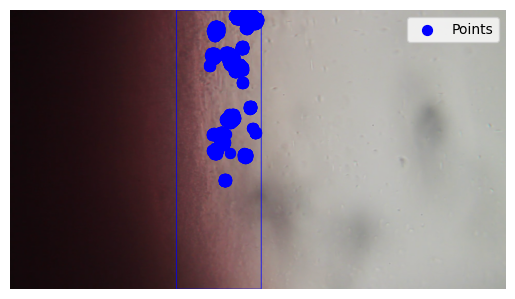

In [38]:
plt.imshow(frame0_color)
plt.scatter(pts[:,1], pts[:,0], color= "blue", s=50, label="Points")
# plt.title('Example video')
plt.legend()
plt.axis('off')
# plt.savefig('goodpts_roi.png', bbox_inches='tight', pad_inches=0)
plt.show()

In [39]:
## Clustering: Hacer una función para clustering
detect = clustering(pts, min_pts=25)

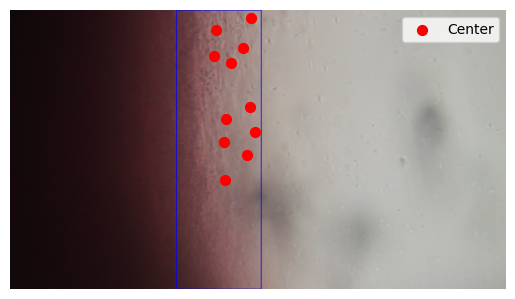

In [40]:
# Mostrar la imagen
plt.imshow(frame0_color)
plt.scatter(detect[:,1], detect[:,0], color= "red", s=50, label="Center")  # Se usa como marcador el punto del intermedio
#plt.title('Example video')
plt.legend()
plt.axis('off')
plt.savefig('cluster_roi.png', bbox_inches='tight', pad_inches=0)
plt.show()

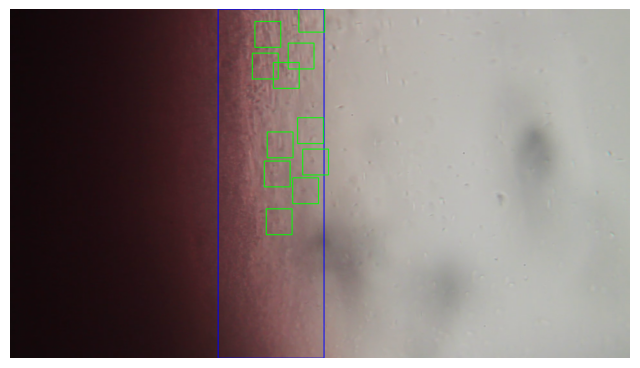

In [41]:
# Longitud del lado del cuadrado
radio = 40 

# Dibujar los cuadrados en la imagen
for (y, x) in detect:
    top_left = (int(x) - radio, int(y) - radio)
    bottom_right = (int(x) + radio, int(y) + radio)
    cv2.rectangle(frame0_color, top_left, bottom_right, (0, 255, 0), 2)  # Color verde, grosor 2px

# Mostrar la imagen con Matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(frame0_color)
#plt.title("Imagen con puntos y cuadrados")
plt.axis("off")
plt.savefig('sections_roi.png', bbox_inches='tight', pad_inches=0)
plt.show()

### Case for InterPos95

In [84]:
frame0_color = (cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)) # Renombrar
cv2.rectangle(frame0_color, (x0, 0), (x1, 1080), (0, 0, 255), thickness=2) # Se suman 25 para longitud de radio

array([[[ 16,   8,   9],
        [ 16,   8,   9],
        [ 16,   8,   9],
        ...,
        [176, 176, 176],
        [176, 176, 176],
        [176, 176, 176]],

       [[ 16,   8,   9],
        [ 16,   8,   9],
        [ 16,   8,   9],
        ...,
        [176, 176, 176],
        [176, 176, 176],
        [176, 176, 176]],

       [[ 16,   8,   9],
        [ 16,   8,   9],
        [ 16,   8,   9],
        ...,
        [176, 176, 174],
        [176, 176, 174],
        [176, 176, 174]],

       ...,

       [[ 18,  10,   9],
        [ 18,  10,   9],
        [ 18,  10,   9],
        ...,
        [166, 166, 162],
        [166, 166, 162],
        [166, 166, 162]],

       [[ 18,  10,  11],
        [ 18,  10,  11],
        [ 18,  10,  11],
        ...,
        [166, 166, 164],
        [166, 166, 164],
        [166, 166, 164]],

       [[ 18,  10,  11],
        [ 18,  10,  11],
        [ 18,  10,  11],
        ...,
        [166, 166, 164],
        [166, 166, 164],
        [166, 166, 164]]

In [86]:
pts = MagnitudeTest(video, InterPos95, 5, x0 = x0, x1 = x1)
pts[:,1] = pts[:,1] + x0

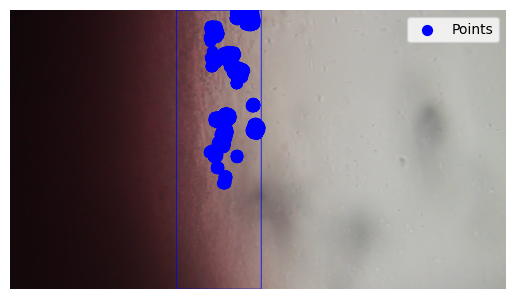

In [88]:
plt.imshow(frame0_color)
plt.scatter(pts[:,1], pts[:,0], color= "blue", s=50, label="Points")
# plt.title('Example video')
plt.legend()
plt.axis('off')
# plt.savefig('goodpts_roi.png', bbox_inches='tight', pad_inches=0)
plt.show()

In [90]:
## Clustering: Hacer una función para clustering
detect = clustering(pts, min_pts=125)

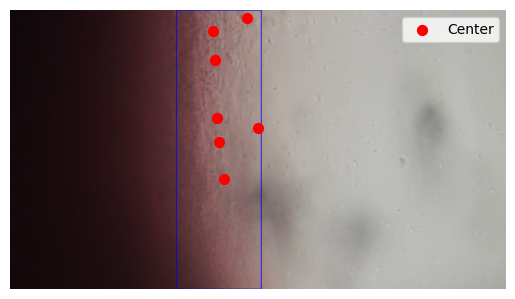

In [92]:
# Mostrar la imagen
plt.imshow(frame0_color)
plt.scatter(detect[:,1], detect[:,0], color= "red", s=50, label="Center")  # Se usa como marcador el punto del intermedio
#plt.title('Example video')
plt.legend()
plt.axis('off')
plt.savefig('cluster_roi.png', bbox_inches='tight', pad_inches=0)
plt.show()

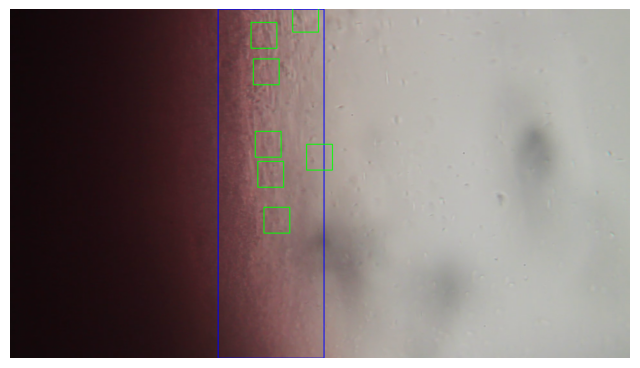

In [94]:
# Longitud del lado del cuadrado
radio = 40 

# Dibujar los cuadrados en la imagen
for (y, x) in detect:
    top_left = (int(x) - radio, int(y) - radio)
    bottom_right = (int(x) + radio, int(y) + radio)
    cv2.rectangle(frame0_color, top_left, bottom_right, (0, 255, 0), 2)  # Color verde, grosor 2px

# Mostrar la imagen con Matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(frame0_color)
#plt.title("Imagen con puntos y cuadrados")
plt.axis("off")
plt.savefig('sections_roi.png', bbox_inches='tight', pad_inches=0)
plt.show()